In [134]:
import numpy as np
import pandas as pd

In [135]:
df = pd.read_csv("C:/Users/shami/Downloads/archive (1)/student_exam_performance_dataset.csv")

In [136]:
df.head(5)

,student_id,gender,age,parental_education,family_income,internet_access,study_environment,study_hours_per_day,attendance_rate,sleep_hours,...,online_courses_completed,tutoring,math_score,reading_score,writing_score,science_score,final_exam_score,previous_gpa,pass_fail,grade_category
0,S00001,Male,17,High School,Medium,Yes,Quiet,2.98,96.5,6.05,...,1,Yes,42.8,62.4,54.8,51.8,49.1,2.44,Fail,F
1,S00002,Female,18,High School,Low,Yes,Quiet,4.45,95.7,6.96,...,0,Yes,77.9,73.5,64.4,61.6,70.1,2.79,Pass,C
2,S00003,Male,17,High School,Medium,No,Quiet,3.75,76.0,7.02,...,4,Yes,53.5,38.3,36.3,47.1,42.2,1.49,Fail,F
3,S00004,Male,18,Bachelor,Medium,Yes,Quiet,2.03,72.6,6.23,...,4,No,28.3,23.5,32.0,39.0,31.9,1.34,Fail,F
4,S00005,Male,18,Bachelor,Medium,Yes,Quiet,5.14,87.3,8.54,...,0,No,74.7,54.9,73.6,55.5,66.4,2.60,Pass,C


In [137]:
df.describe()

,age,study_hours_per_day,attendance_rate,sleep_hours,social_media_hours,assignment_completion_rate,participation_score,online_courses_completed,math_score,reading_score,writing_score,science_score,final_exam_score,previous_gpa
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,16.486900,3.019702,84.703770,7.018894,2.51730,79.491450,69.81681,2.029300,49.503410,49.755600,49.650940,49.759010,49.681910,1.984944
std,1.122744,1.179235,9.509211,0.991714,1.44675,13.763237,14.65927,1.437445,13.879156,13.359603,13.436917,13.825207,12.149823,0.544920
min,15.000000,0.500000,50.800000,4.000000,0.00000,40.000000,20.00000,0.000000,0.000000,0.000000,0.000000,4.800000,4.400000,0.000000
25%,15.000000,2.200000,78.275000,6.337500,1.50000,70.200000,59.80000,1.000000,40.000000,40.800000,40.700000,40.300000,41.600000,1.610000
50%,16.000000,3.010000,85.100000,7.030000,2.50000,80.000000,69.90000,2.000000,49.300000,49.600000,49.600000,49.600000,49.550000,1.990000
75%,17.000000,3.830000,91.900000,7.690000,3.50000,90.000000,80.10000,3.000000,58.600000,58.500000,58.600000,59.000000,57.600000,2.350000
max,18.000000,7.240000,100.000000,10.000000,8.00000,100.000000,100.00000,9.000000,100.000000,100.000000,100.000000,100.000000,97.800000,3.990000


In [138]:
df['pass_fail'] = df['pass_fail'].map({
    'Pass' : 1,
    'Fail' : 0
})

In [139]:
Y = df['pass_fail']

In [140]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
scaler = StandardScaler()

In [141]:
df = df.drop(['final_exam_score','pass_fail','grade_category','student_id'],axis = 1)
print(df)

      gender  age parental_education family_income internet_access  \
0       Male   17        High School        Medium             Yes   
1     Female   18        High School           Low             Yes   
2       Male   17        High School        Medium              No   
3       Male   18           Bachelor        Medium             Yes   
4       Male   18           Bachelor        Medium             Yes   
...      ...  ...                ...           ...             ...   
9995  Female   15             Master          High             Yes   
9996    Male   15        High School        Medium             Yes   
9997  Female   15        High School           Low             Yes   
9998  Female   18           Bachelor        Medium             Yes   
9999    Male   17        High School           Low             Yes   

     study_environment  study_hours_per_day  attendance_rate  sleep_hours  \
0                Quiet                 2.98             96.5         6.05   
1    

In [142]:
df = pd.get_dummies(df,columns = ['parental_education','gender','family_income','internet_access','study_environment','tutoring'])
df.head(5)

,age,study_hours_per_day,attendance_rate,sleep_hours,social_media_hours,assignment_completion_rate,participation_score,online_courses_completed,math_score,reading_score,...,family_income_High,family_income_Low,family_income_Medium,internet_access_No,internet_access_Yes,study_environment_Moderate,study_environment_Noisy,study_environment_Quiet,tutoring_No,tutoring_Yes
0,17,2.98,96.5,6.05,0.1,80.5,68.7,1,42.8,62.4,...,False,False,True,False,True,False,False,True,False,True
1,18,4.45,95.7,6.96,2.9,70.9,92.6,0,77.9,73.5,...,False,True,False,False,True,False,False,True,False,True
2,17,3.75,76.0,7.02,2.4,77.6,45.8,4,53.5,38.3,...,False,False,True,True,False,False,False,True,False,True
3,18,2.03,72.6,6.23,3.5,63.5,72.9,4,28.3,23.5,...,False,False,True,False,True,False,False,True,True,False
4,18,5.14,87.3,8.54,2.1,71.8,55.7,0,74.7,54.9,...,False,False,True,False,True,False,False,True,True,False


In [143]:
X = scaler.fit_transform(df)
print(X.shape)

(10000, 29)


In [144]:
X_train,X_test,Y_train,Y_test = train_test_split(
    X,
    Y,
    test_size = 0.2,
    random_state = 0
)

In [145]:
n = X_train.shape[1]
m = X_train.shape[0]
print(n,m)

29 8000


In [146]:
X_train = X_train.T
X_test = X_test.T
X_test.shape
Y_test = Y_test.to_numpy().reshape(1,2000)

In [147]:
Y_train = Y_train.to_numpy().reshape(1,m)
print(Y_train.shape)
print(Y_train)
df.head()

(1, 8000)
[[1 1 0 ... 0 0 1]]


,age,study_hours_per_day,attendance_rate,sleep_hours,social_media_hours,assignment_completion_rate,participation_score,online_courses_completed,math_score,reading_score,...,family_income_High,family_income_Low,family_income_Medium,internet_access_No,internet_access_Yes,study_environment_Moderate,study_environment_Noisy,study_environment_Quiet,tutoring_No,tutoring_Yes
0,17,2.98,96.5,6.05,0.1,80.5,68.7,1,42.8,62.4,...,False,False,True,False,True,False,False,True,False,True
1,18,4.45,95.7,6.96,2.9,70.9,92.6,0,77.9,73.5,...,False,True,False,False,True,False,False,True,False,True
2,17,3.75,76.0,7.02,2.4,77.6,45.8,4,53.5,38.3,...,False,False,True,True,False,False,False,True,False,True
3,18,2.03,72.6,6.23,3.5,63.5,72.9,4,28.3,23.5,...,False,False,True,False,True,False,False,True,True,False
4,18,5.14,87.3,8.54,2.1,71.8,55.7,0,74.7,54.9,...,False,False,True,False,True,False,False,True,True,False


In [148]:
w = np.zeros((n,1))
b = 0
a = 0.05
losses = []

In [149]:
for i in range(3000):
    Z = np.dot(w.T,X_train) + b
    A = 1/(1 + np.exp(-Z))
    dz = A - Y_train
    L = -(Y_train * np.log(A) + (1 - Y_train) * np.log(1 - A))
    J = 1/m * np.sum(L)
    losses.append(J)
    dw = 1/m * np.dot(X_train,dz.T)
    db = 1/m * np.sum(dz)
    w -= a * dw
    b -= a * db
print("w =",w)
print("b =",b)

w = [[-9.56098213e-02]
 [ 1.56308867e-01]
 [ 4.13952245e-02]
 [ 2.90854281e-02]
 [-1.10304270e-01]
 [ 1.00109750e-01]
 [ 7.65339804e-02]
 [ 9.64497299e-02]
 [ 2.11149202e+00]
 [ 2.01704204e+00]
 [ 2.01602269e+00]
 [ 2.04197893e+00]
 [ 1.25228214e+00]
 [ 5.65099819e-02]
 [-5.40599231e-02]
 [ 1.09132551e-02]
 [-2.22449973e-02]
 [-8.20000539e-03]
 [ 8.20000539e-03]
 [-2.44355026e-02]
 [ 2.16277773e-02]
 [-3.63006224e-04]
 [-5.78248125e-03]
 [ 5.78248125e-03]
 [-3.86876224e-02]
 [-8.44048370e-03]
 [ 4.53328106e-02]
 [ 1.11951467e-03]
 [-1.11951467e-03]]
b = -0.19010734344920857


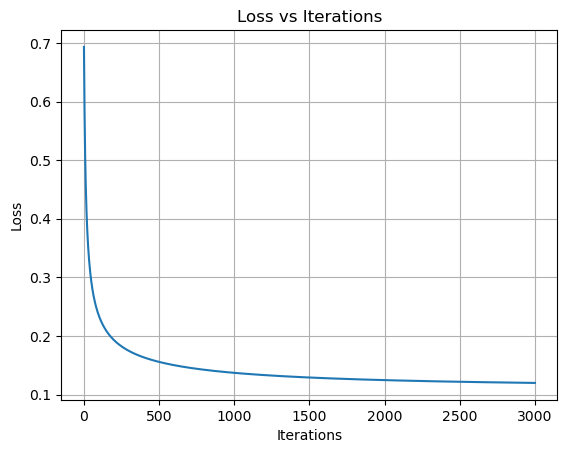

In [150]:
import matplotlib.pyplot as plt
plt.plot(losses)

plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Loss vs Iterations")

plt.grid(True)

plt.show()

In [151]:
class LogisticRegression():
    def __init__(self,w,b,X,Y):
        self.w = w
        self.b = b
        self.X = X
        self.Y = Y
    def predict(self,X_test):
        Y_pred = 1/(1 + np.exp(-np.dot(w.T,X_test) + b))
        Y_pred = np.where(Y_pred > 0.5, 1, 0)
        return Y_pred

In [152]:
model = LogisticRegression(w,b,X_train,Y_train)

In [153]:
Y_pred = model.predict(X_test)

In [154]:
# for i in range(0,2000):
#     if Y_pred[i] == Y_test[i]:
#         print("True")
#     else:
#         print("False")
print(np.where(Y_pred != Y_test))
print(Y_pred.shape)
print(Y_test.shape)

(array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]), array([  14,   20,   32,   71,   96,  118,  120,  126,  136,  162,  186,
        189,  212,  217,  223,  248,  255,  263,  279,  283,  307,  316,
        331,  351,  400,  402,  412,  420,  441,  453,  465,  568,  597,
        610,  617,  621,  683,  725,  727,  735,  738,  743,  766,  783,
        828,  844,  859,  896,  898,  901,  905,  911,  923,  931,  946,
        967,  980,  985,  996,  998, 1012, 1013, 1056, 1063, 1068, 1087,
       1091, 1097, 1098, 1103, 1136, 1177, 1181, 1187, 1210, 1222, 1226,
       1257, 1273, 1291, 1294, 1307, 1322, 1329, 1348, 1361, 1409, 1411,

In [155]:
np.sum(Y_pred == 1)

np.int64(1011)

In [156]:
np.sum(Y_test == 1)

np.int64(969)

In [157]:
np.sum(Y_pred == Y_test)

np.int64(1876)